# Polyglot Persistence

The following tutorial is based on a real world scenarios in which the author participated between 2005-2020.

## Scenario
An organization observed extreme performance drops in an XML-based document viewer when large document were processed and/or a large amount of simultaneous user accesses occurred.

The internal development team allocated additional resources for their production VM. Unfortunately, this did not improve the performance. After the author inspected the software architecture it became onvious that the root cause of the problem sat within the persistence layer, i.e., the used DBMS.

## Prerequisites

* The notebook assumes a running redis instance with standard settings, a PostgreSQL instance (you can adjust the connection parameters below) and a mongodb instance with standard settings.

## Setup

The following cell configures the notebook and sets up experiments. Each experiment randomly accesses documents for display in order to illustrate the impact of the used database system (see ``stats``) on the retrieval time.
The number of access is varied over each experimental run (see ``experimental_runs``).

In [1]:
import os
import pickle
import xml.etree.ElementTree as ET
from lxml import etree
import redis
import sqlite3
import duckdb
import psycopg2
from pymongo import MongoClient

import random
from tqdm import tqdm
from datetime import datetime
from faker import Faker

import pandas as pd
import matplotlib.pyplot as plt


# as the XML processing is expensive, the notebook will save a backup of all needed data
# however, on the first run, all data has to be generated (first_run=True), in any subsequent run, you can rely on the backup (use_xml_backup=True)
first_run= False
use_xml_backup = True

if first_run and use_xml_backup:
    print("⚠️\tYou must not set first_run and use_xml_backup to 'True' at the same time.\n\tThe XML backup will be created at the first run.\n")

# controls output details
verbose=True

# adjust your PostgreSQL connection parameters here
pg_host="localhost"
pg_port=5432
pg_database="david"
pg_user="david"
pg_password="david"


# creates a dictionary for the experiments to be run
# this dict has to contain all database systems you want to test
# ATTENTION: xml variants must be the two first entries
stats={'db':[],
            }
stats['db'].append('xml')
stats['db'].append('lxml')
stats['db'].append('redis')
stats['db'].append('sqlite3')
stats['db'].append('duckdb')
stats['db'].append('postgres')
stats['db'].append('mongodb')
stats['db'].append('mongodb (idx)')

# the number of document accesses in each experimental run. in other words: each DB systems from stats will be confronted with these runs
experimental_runs=[
    1,
    10,
    100,
    1000,
    10000,
    100000,
    200000,
    500000,
]

# add an array for each experiment to stats that will be holding the retrieval time for each run and DB
for experiment in experimental_runs:
    stats[experiment]=[]

# stores the time it takes to set up the DB
init_times={'db':[],
            'duration':[]
            }
init_times['db'].append('xml')
init_times['db'].append('lxml')
init_times['db'].append('redis')
init_times['db'].append('sqlite3')
init_times['db'].append('duckdb')
init_times['db'].append('postgres')
init_times['db'].append('mongodb')
init_times['db'].append('mongodb (idx)')


# generate fake ID and title data (only relevant for RDBMS)
fake = Faker()

fake_k=100000
fake_numbers = random.sample(range(100_000_000, 1_000_000_000), k=fake_k)
fake_ppns=["PPx"+str(x) for x in fake_numbers]
fake_titles=[fake.sentence() for _ in range(fake_k)]


# process an XML document directly and interpret it as the initialization time
startTime = datetime.now()
xmlPath="../data/xml/sample/__metsmods/PPN745182844.xml"

tree = ET.parse(xmlPath)
root = tree.getroot()


# max index, i.e., the last "page"
maxIndex=1
# we are only interested in fileGrp nodes below fileSec...
for fileSec in root.iter("{http://www.loc.gov/METS/}fileSec"):
    for child in fileSec.iter("{http://www.loc.gov/METS/}fileGrp"):
        currentUse = child.attrib["USE"]

        firstFileNode = True
        if currentUse== "PRESENTATION":
            # which contains file nodes...
            for fileNode in child.iter("{http://www.loc.gov/METS/}file"):
                # embedding FLocat node pointing to the URLs of interest
                id = fileNode.attrib["ID"]
                currentIndex=int(id.split("_")[1])
                maxIndex =  currentIndex
                #print(f"\thref: {str(fileNode[0].attrib["{http://www.w3.org/1999/xlink}href"])}")

endTime = datetime.now()
duration = endTime - startTime

init_xml=duration.total_seconds()
init_times['duration'].append(init_xml)

print(f"Duration:\t{str(duration)}")
print("\nStarted at:\t%s\nEnded at:\t%s" % (startTime, endTime))
print(f"Max index:\t{maxIndex}")

Duration:	0:00:00.007644

Started at:	2026-05-18 13:09:13.829494
Ended at:	2026-05-18 13:09:13.837138
Max index:	341


## XML

__ATTENTION:__ Do not move this block otherwise the XML backup mechanism will not work. Only add other DBs after the LXML block.

The next cell wil take an XML document and retrieve a reference to an image to be displayed.

In [2]:
def getPageFromXML(index):
    xmlPath="../data/xml/sample/__metsmods/PPN745182844.xml"

    tree = ET.parse(xmlPath)
    root = tree.getroot()
    for fileSec in root.iter("{http://www.loc.gov/METS/}fileSec"):
        for child in fileSec.iter("{http://www.loc.gov/METS/}fileGrp"):
            currentUse = child.attrib["USE"]

            firstFileNode = True
            if currentUse== "PRESENTATION":
                # which contains file nodes...
                for fileNode in child.iter("{http://www.loc.gov/METS/}file"):
                    # embedding FLocat node pointing to the URLs of interest
                    id = fileNode.attrib["ID"]
                    currentIndex=int(id.split("_")[1])
                    if currentIndex==index:
                        # returns the href to the presentation index
                        return str(fileNode[0].attrib["{http://www.w3.org/1999/xlink}href"])

Run the experiments, i.e., call the function above repeatedly.

In [3]:
if not use_xml_backup or first_run:
    for experiment in experimental_runs:
        startTime = datetime.now()
        for i in tqdm(range(experiment)):
            selectedPage=random.randint(1, maxIndex)
            returnedHref=getPageFromXML(selectedPage)
        endTime = datetime.now()

        duration = endTime - startTime
        stats[experiment].append(duration.total_seconds())

        print("%i runs\nStarted at:\t%s\nEnded at:\t%s" % (experiment,startTime, endTime))
        print(f"Duration:\t{str(duration)}\n")
else:
    print("Restoring from XML backup.")
    stats=pickle.load(open("../data/stats_after_xml.pickle", "rb"))

expected_len=stats['db'].index('xml')+1
if expected_len != len(stats[1]):
    display(stats)
    print("⚠️\tExpected array size invalid! Did you run one or more cells repeatedly?\n\tYou will have to restart the notebook.")

Restoring from XML backup.


In [4]:
# as the XML processing takes quite a while we will make a backup to continue from this cell on the first run.
if first_run:
    pickle.dump(stats, open("../data/stats_after_xml.pickle", "wb"))
    print("Saved XML backup.")

## LXML

__ATTENTION:__ Do not move this block otherwise the XML backup mechanism will not work. Only add other DBs after the LXML block.

The next cell wil take an XML document and retrieve a reference to an image to be displayed.

In [5]:
def getPageFromLXML(index):
    xmlPath="../data/xml/sample/__metsmods/PPN745182844.xml"

    tree = etree.parse(xmlPath)
    root = tree.getroot()
    for fileSec in root.iter("{http://www.loc.gov/METS/}fileSec"):
        for child in fileSec.iter("{http://www.loc.gov/METS/}fileGrp"):
            currentUse = child.attrib["USE"]

            firstFileNode = True
            if currentUse== "PRESENTATION":
                # which contains file nodes...
                for fileNode in child.iter("{http://www.loc.gov/METS/}file"):
                    # embedding FLocat node pointing to the URLs of interest
                    id = fileNode.attrib["ID"]
                    currentIndex=int(id.split("_")[1])
                    if currentIndex==index:
                        # returns the href to the presentation index
                        return str(fileNode[0].attrib["{http://www.w3.org/1999/xlink}href"])

if not use_xml_backup or first_run:
    for experiment in experimental_runs:
        startTime = datetime.now()
        for i in tqdm(range(experiment)):
            selectedPage=random.randint(1, maxIndex)
            returnedHref=getPageFromLXML(selectedPage)
        endTime = datetime.now()

        duration = endTime - startTime
        stats[experiment].append(duration.total_seconds())

        print("%i runs\nStarted at:\t%s\nEnded at:\t%s" % (experiment,startTime, endTime))
        print(f"Duration:\t{str(duration)}\n")
else:
    print("Restoring from XML backup.")
    stats=pickle.load(open("../data/stats_after_lxml.pickle", "rb"))
# dummy init time
init_times['duration'].append(init_xml)

expected_len=stats['db'].index('lxml')+1
if expected_len != len(stats[1]):
    display(stats)
    print("⚠️\tExpected array size invalid! Did you run one or more cells repeatedly?\n\tYou will have to restart the notebook.")

Restoring from XML backup.


Run the experiments, i.e., call the function above repeatedly.


In [6]:
# as the XML processing takes quite a while we will make a backup to continue from this cell on the first run.
if first_run:
    pickle.dump(stats, open("../data/stats_after_lxml.pickle", "wb"))
    print("Saved XML backup (for LXML run).")

## Redis

Set up a redis DB on basis of the parsed XML file. Then, the experiments will be run.

In [7]:
startTime = datetime.now()
# delete all data from redis
r = redis.Redis(host='localhost', port=6379, decode_responses=True)
r.flushall()

# parse the XML and store page ID and link to the images in redis' key-value store
tree = ET.parse(xmlPath)
root = tree.getroot()

# max index, i.e., the last "page"
maxIndex=1
# we are only interested in fileGrp nodes below fileSec...
for fileSec in root.iter("{http://www.loc.gov/METS/}fileSec"):
    for child in fileSec.iter("{http://www.loc.gov/METS/}fileGrp"):
        currentUse = child.attrib["USE"]

        firstFileNode = True
        if currentUse== "PRESENTATION":
            # which contains file nodes...
            for fileNode in child.iter("{http://www.loc.gov/METS/}file"):
                # embedding FLocat node pointing to the URLs of interest
                id = fileNode.attrib["ID"]
                currentIndex=int(id.split("_")[1])
                maxIndex =  currentIndex
                r.set(currentIndex,str(fileNode[0].attrib["{http://www.w3.org/1999/xlink}href"]))
endTime = datetime.now()
duration = endTime - startTime
init_redis=duration.total_seconds()
init_times['duration'].append(init_redis)

for experiment in experimental_runs:
    startTime = datetime.now()
    for i in tqdm(range(experiment)):
        selectedPage=random.randint(1, maxIndex)
        returnedHref=r.get(selectedPage)

    endTime = datetime.now()
    duration = endTime - startTime
    stats[experiment].append(duration.total_seconds())

    print("%i runs\nStarted at:\t%s\nEnded at:\t%s\n" % (experiment,startTime, endTime))
    print(f"Duration:\t{str(duration)}\n")

r.close()

expected_len=stats['db'].index('redis')+1
if expected_len != len(stats[1]):
    display(stats)
    print("⚠️\tExpected array size invalid! Did you run one or more cells repeatedly?\n\tYou will have to restart the notebook.")

100%|██████████| 1/1 [00:00<00:00, 1965.47it/s]


1 runs
Started at:	2026-05-18 13:09:13.982551
Ended at:	2026-05-18 13:09:14.003691

Duration:	0:00:00.021140



100%|██████████| 10/10 [00:00<00:00, 4128.66it/s]


10 runs
Started at:	2026-05-18 13:09:14.003726
Ended at:	2026-05-18 13:09:14.007475

Duration:	0:00:00.003749



100%|██████████| 100/100 [00:00<00:00, 21262.82it/s]


...

100000 runs
Started at:	2026-05-18 13:09:14.334853
Ended at:	2026-05-18 13:09:17.219294

Duration:	0:00:02.884441



100%|██████████| 200000/200000 [00:05<00:00, 35616.76it/s]


200000 runs
Started at:	2026-05-18 13:09:17.219323
Ended at:	2026-05-18 13:09:22.835399

Duration:	0:00:05.616076



100%|██████████| 500000/500000 [00:13<00:00, 35898.69it/s]

500000 runs
Started at:	2026-05-18 13:09:22.835420
Ended at:	2026-05-18 13:09:36.764162

Duration:	0:00:13.928742



## SQLite

Set up a SQLite DB on basis of the parsed XML file. Then, the experiments will be run.

In [8]:
startTime = datetime.now()

tree = ET.parse(xmlPath)
root = tree.getroot()

# create the database on basis of the parsed XML
con = sqlite3.connect("../data/sqlite/test.db")
cur = con.cursor()

cur.execute("DROP TABLE IF EXISTS media;")
cur.execute("CREATE TABLE media (ppn PRIMARY KEY, dummy_data NOT NULL);")

cur.execute("DROP TABLE IF EXISTS documents;")
cur.execute("CREATE TABLE documents (ppn NOT NULL, page NOT NULL, href NOT NULL,  FOREIGN KEY (ppn) REFERENCES media);")

sample_ppn = "PPN745182844"
dummy_text = "Title"
cur.execute("INSERT INTO media VALUES (?, ?);", (sample_ppn,dummy_text))

# add fake documents:
for i in range(fake_k):
    cur.execute("INSERT INTO media VALUES (?, ?);", (fake_ppns[i],fake_titles[i]))

# we are only interested in fileGrp nodes below fileSec...
for fileSec in root.iter("{http://www.loc.gov/METS/}fileSec"):
    for child in fileSec.iter("{http://www.loc.gov/METS/}fileGrp"):
        currentUse = child.attrib["USE"]

        firstFileNode = True
        if currentUse== "PRESENTATION":
            # which contains file nodes...
            for fileNode in child.iter("{http://www.loc.gov/METS/}file"):
                # embedding FLocat node pointing to the URLs of interest
                id = fileNode.attrib["ID"]
                currentIndex=int(id.split("_")[1])
                maxIndex =  currentIndex
                cur.execute("INSERT INTO documents VALUES('"+sample_ppn+"',"+str(currentIndex)+",'"+str(fileNode[0].attrib["{http://www.w3.org/1999/xlink}href"])+"');")

cur.close()
con.commit()
con.close()

endTime = datetime.now()
duration = endTime - startTime
init_sqlite=duration.total_seconds()

init_times['duration'].append(init_sqlite)

con = sqlite3.connect("../data/sqlite/test.db")
cur = con.cursor()

for experiment in experimental_runs:
    startTime = datetime.now()
    print(experiment)

    for i in tqdm(range(experiment)):
        selectedPage=random.randint(1, maxIndex)
        #print("SELECT * FROM documents WHERE page="+str(selectedPage)+";")
        #sql_cmd="SELECT * FROM documents WHERE page="+str(selectedPage)+";"
        sql_cmd="SELECT href FROM documents JOIN media ON documents.ppn=media.ppn WHERE page="+str(selectedPage)+";"
        returnedHref=cur.execute(sql_cmd).fetchone()

    endTime = datetime.now()
    duration = endTime - startTime
    stats[experiment].append(duration.total_seconds())

    print("%i runs\nStarted at:\t%s\nEnded at:\t%s\n" % (experiment,startTime, endTime))
    print(f"Duration:\t{str(duration)}\n")

cur.close()
con.close()

expected_len=stats['db'].index('sqlite3')+1
if expected_len != len(stats[1]):
    display(stats)
    print("⚠️\tExpected array size invalid! Did you run one or more cells repeatedly?\n\tYou will have to restart the notebook.")

1


100%|██████████| 1/1 [00:00<00:00, 4788.02it/s]


1 runs
Started at:	2026-05-18 13:09:37.006544
Ended at:	2026-05-18 13:09:37.007504

Duration:	0:00:00.000960

10


100%|██████████| 10/10 [00:00<00:00, 10247.51it/s]


10 runs
Started at:	2026-05-18 13:09:37.007523
Ended at:	2026-05-18 13:09:37.009086

Duration:	0:00:00.001563

100


...

100000 runs
Started at:	2026-05-18 13:09:37.147437
Ended at:	2026-05-18 13:09:38.313512

Duration:	0:00:01.166075

200000


100%|██████████| 200000/200000 [00:02<00:00, 87062.48it/s]


200000 runs
Started at:	2026-05-18 13:09:38.313537
Ended at:	2026-05-18 13:09:40.611522

Duration:	0:00:02.297985

500000


100%|██████████| 500000/500000 [00:06<00:00, 82128.28it/s]

500000 runs
Started at:	2026-05-18 13:09:40.611548
Ended at:	2026-05-18 13:09:46.700526

Duration:	0:00:06.088978



## DuckDB

Set up a DuckDB (in memory) on basis of the parsed XML file. Then, the experiments will be run.

In [9]:
startTime = datetime.now()

tree = ET.parse(xmlPath)
root = tree.getroot()

duckdb.close()
duckdb.sql("DROP TABLE IF EXISTS media CASCADE;")
duckdb.sql("CREATE TABLE media (ppn VARCHAR(12) PRIMARY KEY, dummy_data VARCHAR (50) NOT NULL);")

duckdb.sql("DROP TABLE IF EXISTS documents CASCADE;")
duckdb.sql("CREATE TABLE documents (ppn VARCHAR(12) NOT NULL, page INT NOT NULL, href VARCHAR(200) NOT NULL,  FOREIGN KEY (ppn) REFERENCES media);")

sample_ppn = "PPN745182844"
dummy_text = "Title"
duckdb.sql("INSERT INTO media VALUES (?, ?)", params=[sample_ppn,dummy_text])

for i in range(fake_k):
    duckdb.sql("INSERT INTO media VALUES (?, ?);", params=[fake_ppns[i],fake_titles[i]])

# we are only interested in fileGrp nodes below fileSec...
for fileSec in root.iter("{http://www.loc.gov/METS/}fileSec"):
    for child in fileSec.iter("{http://www.loc.gov/METS/}fileGrp"):
        currentUse = child.attrib["USE"]

        firstFileNode = True
        if currentUse== "PRESENTATION":
            # which contains file nodes...
            for fileNode in child.iter("{http://www.loc.gov/METS/}file"):
                # embedding FLocat node pointing to the URLs of interest
                id = fileNode.attrib["ID"]
                currentIndex=int(id.split("_")[1])
                maxIndex =  currentIndex
                duckdb.sql("INSERT INTO documents VALUES('"+sample_ppn+"',"+str(currentIndex)+",'"+str(fileNode[0].attrib["{http://www.w3.org/1999/xlink}href"])+"');")

endTime = datetime.now()
duration = endTime - startTime
init_duckdb=duration.total_seconds()

init_times['duration'].append(init_duckdb)

for experiment in experimental_runs:
    startTime = datetime.now()
    print(experiment)

    for i in tqdm(range(experiment)):
        selectedPage=random.randint(1, maxIndex)
        #print("SELECT * FROM documents WHERE page="+str(selectedPage)+";")
        #sql_cmd="SELECT * FROM documents WHERE page="+str(selectedPage)+";"
        sql_cmd="SELECT href FROM documents JOIN media ON documents.ppn=media.ppn WHERE page=?;"

        returnedHref=duckdb.sql(sql_cmd,params=[selectedPage]).fetchone()



    endTime = datetime.now()
    duration = endTime - startTime
    stats[experiment].append(duration.total_seconds())
    print("apend")

    print("%i runs\nStarted at:\t%s\nEnded at:\t%s\n" % (experiment,startTime, endTime))
    print(f"Duration:\t{str(duration)}\n")

duckdb.close() # closes and deletes the in-memory db

expected_len=stats['db'].index('duckdb')+1
if expected_len != len(stats[1]):
    display(stats)
    print("⚠️\tExpected array size invalid! Did you run one or more cells repeatedly?\n\tYou will have to restart the notebook.")


1


100%|██████████| 1/1 [00:00<00:00, 1766.77it/s]


apend
1 runs
Started at:	2026-05-18 13:09:57.266519
Ended at:	2026-05-18 13:09:57.267901

Duration:	0:00:00.001382

10


100%|██████████| 10/10 [00:00<00:00, 3591.94it/s]


apend
10 runs
Started at:	2026-05-18 13:09:57.267921
Ended at:	2026-05-18 13:09:57.271337

Duration:	0:00:00.003416

100


...

apend
100000 runs
Started at:	2026-05-18 13:09:59.268323
Ended at:	2026-05-18 13:10:17.059473

Duration:	0:00:17.791150

200000


100%|██████████| 200000/200000 [00:35<00:00, 5635.93it/s]


apend
200000 runs
Started at:	2026-05-18 13:10:17.059499
Ended at:	2026-05-18 13:10:52.546928

Duration:	0:00:35.487429

500000


100%|██████████| 500000/500000 [01:30<00:00, 5511.10it/s]

apend
500000 runs
Started at:	2026-05-18 13:10:52.546957
Ended at:	2026-05-18 13:12:23.274000

Duration:	0:01:30.727043



## PostgreSQL

Set up a PostgreSQL DB on basis of the parsed XML file. Then, the experiments will be run.

In [10]:
startTime = datetime.now()

con = psycopg2.connect(
    host=pg_host,
    port=pg_port,
    database=pg_database,
    user=pg_user,
    password=pg_password
)

cur = con.cursor()

tree = ET.parse(xmlPath)
root = tree.getroot()

cur.execute("DROP TABLE IF EXISTS media CASCADE;")
cur.execute("CREATE TABLE media (ppn VARCHAR(12) PRIMARY KEY, dummy_data VARCHAR (200) NOT NULL);")

cur.execute("DROP TABLE IF EXISTS documents;")
cur.execute("CREATE TABLE documents (ppn VARCHAR(12) NOT NULL, page INT NOT NULL, href VARCHAR(200) NOT NULL,  FOREIGN KEY (ppn) REFERENCES media);")

sample_ppn = "PPN745182844"
dummy_text = "Title"
sql_cmd="""INSERT INTO media VALUES(%s,%s);"""
cur.execute(sql_cmd, (sample_ppn,dummy_text))

# add fake documents:
for i in range(fake_k):
    cur.execute(sql_cmd, (fake_ppns[i],fake_titles[i]))

# we are only interested in fileGrp nodes below fileSec...
for fileSec in root.iter("{http://www.loc.gov/METS/}fileSec"):
    for child in fileSec.iter("{http://www.loc.gov/METS/}fileGrp"):
        currentUse = child.attrib["USE"]

        firstFileNode = True
        if currentUse== "PRESENTATION":
            # which contains file nodes...
            for fileNode in child.iter("{http://www.loc.gov/METS/}file"):
                # embedding FLocat node pointing to the URLs of interest
                id = fileNode.attrib["ID"]
                currentIndex=int(id.split("_")[1])
                maxIndex =  currentIndex
                cur.execute("INSERT INTO documents VALUES('"+sample_ppn+"',"+str(currentIndex)+",'"+str(fileNode[0].attrib["{http://www.w3.org/1999/xlink}href"])+"');")

cur.close()
con.commit()
con.close()

endTime = datetime.now()
duration = endTime - startTime
init_postgres=duration.total_seconds()

init_times['duration'].append(init_postgres)

con = psycopg2.connect(
    host=pg_host,
    port=pg_port,
    database=pg_database,
    user=pg_user,
    password=pg_password
)


cur = con.cursor()

for experiment in experimental_runs:
    startTime = datetime.now()
    print(experiment)

    for i in tqdm(range(experiment)):
        selectedPage=random.randint(1, maxIndex)
        #print("SELECT * FROM documents WHERE page="+str(selectedPage)+";")
        #sql_cmd="SELECT * FROM documents WHERE page="+str(selectedPage)+";"
        sql_cmd="""SELECT href FROM documents JOIN media ON documents.ppn=media.ppn WHERE page=%s;"""
        try:
            cur.execute(sql_cmd,(selectedPage,))
            returnedHref=cur.fetchone()
        except psycopg2.Error as e:
            print(f"An error occurred: {e.pgcode} - {e.pgerror}")

    endTime = datetime.now()
    duration = endTime - startTime
    stats[experiment].append(duration.total_seconds())
    print("apend")

    print("%i runs\nStarted at:\t%s\nEnded at:\t%s\n" % (experiment,startTime, endTime))
    print(f"Duration:\t{str(duration)}\n")

cur.close()
con.close()

expected_len=stats['db'].index('postgres')+1
if expected_len != len(stats[1]):
    display(stats)
    print("⚠️\tExpected array size invalid! Did you run one or more cells repeatedly?\n\tYou will have to restart the notebook.")

1


100%|██████████| 1/1 [00:00<00:00, 1550.00it/s]


apend
1 runs
Started at:	2026-05-18 13:12:25.947138
Ended at:	2026-05-18 13:12:25.948628

Duration:	0:00:00.001490

10


100%|██████████| 10/10 [00:00<00:00, 13774.40it/s]


apend
10 runs
Started at:	2026-05-18 13:12:25.948648
Ended at:	2026-05-18 13:12:25.949911

Duration:	0:00:00.001263

100


...

apend
100000 runs
Started at:	2026-05-18 13:12:26.463345
Ended at:	2026-05-18 13:12:30.972399

Duration:	0:00:04.509054

200000


100%|██████████| 200000/200000 [00:09<00:00, 22112.27it/s]


apend
200000 runs
Started at:	2026-05-18 13:12:30.972430
Ended at:	2026-05-18 13:12:40.017877

Duration:	0:00:09.045447

500000


100%|██████████| 500000/500000 [00:22<00:00, 22467.60it/s]

apend
500000 runs
Started at:	2026-05-18 13:12:40.017903
Ended at:	2026-05-18 13:13:02.272853

Duration:	0:00:22.254950



## MongoDB

Set up a mongoDB on basis of the parsed XML file. Then, the experiments will be run.

In [11]:
mongo_url="mongodb://localhost:27017"

startTime = datetime.now()

client = MongoClient(mongo_url)
client.drop_database("test_db")
database = client["test_db"]
database.create_collection("media")
collection = database["media"]


tree = ET.parse(xmlPath)
root = tree.getroot()

# max index, i.e., the last "page"
maxIndex=1
# we are only interested in fileGrp nodes below fileSec...
for fileSec in root.iter("{http://www.loc.gov/METS/}fileSec"):
    for child in fileSec.iter("{http://www.loc.gov/METS/}fileGrp"):
        currentUse = child.attrib["USE"]

        firstFileNode = True
        if currentUse== "PRESENTATION":
            # which contains file nodes...
            for fileNode in child.iter("{http://www.loc.gov/METS/}file"):
                # embedding FLocat node pointing to the URLs of interest
                id = fileNode.attrib["ID"]
                currentIndex=int(id.split("_")[1])
                maxIndex =  currentIndex
                collection.insert_one({ "page": currentIndex, "href" : str(fileNode[0].attrib["{http://www.w3.org/1999/xlink}href"]) })

endTime = datetime.now()
duration = endTime - startTime
init_mongo=duration.total_seconds()
init_times['duration'].append(init_mongo)

for experiment in experimental_runs:
    startTime = datetime.now()
    for i in tqdm(range(experiment)):
        selectedPage=random.randint(1, maxIndex)
        returnedHref=collection.find_one({ "page" : selectedPage})

    endTime = datetime.now()
    duration = endTime - startTime
    stats[experiment].append(duration.total_seconds())

    print("%i runs\nStarted at:\t%s\nEnded at:\t%s\n" % (experiment,startTime, endTime))
    print(f"Duration:\t{str(duration)}\n")

client.close()

expected_len=stats['db'].index('mongodb')+1
if expected_len != len(stats[1]):
    display(stats)
    print("⚠️\tExpected array size invalid! Did you run one or more cells repeatedly?\n\tYou will have to restart the notebook.")


100%|██████████| 1/1 [00:00<00:00, 1781.78it/s]


1 runs
Started at:	2026-05-18 13:13:02.375998
Ended at:	2026-05-18 13:13:02.377201

Duration:	0:00:00.001203



100%|██████████| 10/10 [00:00<00:00, 3550.88it/s]


10 runs
Started at:	2026-05-18 13:13:02.377220
Ended at:	2026-05-18 13:13:02.380612

Duration:	0:00:00.003392



100%|██████████| 100/100 [00:00<00:00, 4837.94it/s]


...

100000 runs
Started at:	2026-05-18 13:13:04.409675
Ended at:	2026-05-18 13:13:22.425788

Duration:	0:00:18.016113



100%|██████████| 200000/200000 [00:36<00:00, 5442.05it/s]


200000 runs
Started at:	2026-05-18 13:13:22.425809
Ended at:	2026-05-18 13:13:59.177412

Duration:	0:00:36.751603



100%|██████████| 500000/500000 [01:32<00:00, 5419.76it/s]

500000 runs
Started at:	2026-05-18 13:13:59.177434
Ended at:	2026-05-18 13:15:31.433222

Duration:	0:01:32.255788



## MongoDB (Indexed)

Set up a mongoDB on basis of the parsed XML file. To increase retrieval performance, an index on the page ID will be created. Then, the experiments will be run.


In [12]:
mongo_url="mongodb://localhost:27017"

startTime = datetime.now()

client = MongoClient(mongo_url)
client.drop_database("test_db")
database = client["test_db"]
database.create_collection("media")
collection = database["media"]


tree = ET.parse(xmlPath)
root = tree.getroot()

# max index, i.e., the last "page"
maxIndex=1
# we are only interested in fileGrp nodes below fileSec...
for fileSec in root.iter("{http://www.loc.gov/METS/}fileSec"):
    for child in fileSec.iter("{http://www.loc.gov/METS/}fileGrp"):
        currentUse = child.attrib["USE"]

        firstFileNode = True
        if currentUse== "PRESENTATION":
            # which contains file nodes...
            for fileNode in child.iter("{http://www.loc.gov/METS/}file"):
                # embedding FLocat node pointing to the URLs of interest
                id = fileNode.attrib["ID"]
                currentIndex=int(id.split("_")[1])
                maxIndex =  currentIndex
                collection.insert_one({ "page": currentIndex, "href" : str(fileNode[0].attrib["{http://www.w3.org/1999/xlink}href"]) })

collection.create_index("page")

endTime = datetime.now()
duration = endTime - startTime
init_mongo=duration.total_seconds()
init_times['duration'].append(init_mongo)

for experiment in experimental_runs:
    startTime = datetime.now()
    for i in tqdm(range(experiment)):
        selectedPage=random.randint(1, maxIndex)
        returnedHref=collection.find_one({ "page" : selectedPage})

    endTime = datetime.now()
    duration = endTime - startTime
    stats[experiment].append(duration.total_seconds())

    print("%i runs\nStarted at:\t%s\nEnded at:\t%s\n" % (experiment,startTime, endTime))
    print(f"Duration:\t{str(duration)}\n")

client.close()

expected_len=stats['db'].index('mongodb (idx)')+1
if expected_len != len(stats[1]):
    display(stats)
    print("⚠️\tExpected array size invalid! Did you run one or more cells repeatedly?\n\tYou will have to restart the notebook.")

100%|██████████| 1/1 [00:00<00:00, 1137.28it/s]


1 runs
Started at:	2026-05-18 13:15:31.528786
Ended at:	2026-05-18 13:15:31.530493

Duration:	0:00:00.001707



100%|██████████| 10/10 [00:00<00:00, 4297.44it/s]


10 runs
Started at:	2026-05-18 13:15:31.530516
Ended at:	2026-05-18 13:15:31.533526

Duration:	0:00:00.003010



100%|██████████| 100/100 [00:00<00:00, 5546.63it/s]


...

100000 runs
Started at:	2026-05-18 13:15:33.293428
Ended at:	2026-05-18 13:15:48.983838

Duration:	0:00:15.690410



100%|██████████| 200000/200000 [00:31<00:00, 6343.08it/s]


200000 runs
Started at:	2026-05-18 13:15:48.983859
Ended at:	2026-05-18 13:16:20.514982

Duration:	0:00:31.531123



100%|██████████| 500000/500000 [01:18<00:00, 6382.30it/s]

500000 runs
Started at:	2026-05-18 13:16:20.515001
Ended at:	2026-05-18 13:17:38.857393

Duration:	0:01:18.342392



## Analysis

In [13]:
if len(stats['db']) != len(stats[1]):
    print("⚠️\tExpected array size invalid! Did you run one or more cells repeatedly?\n\tYou will have to restart the notebook as the next call will crash soon.\n")

df = pd.DataFrame(stats)
df

,db,1,10,100,1000,10000,100000,200000,500000
0,xml,0.029430,0.111384,0.758837,7.657496,75.793651,759.285696,1521.204278,3852.393824
1,lxml,0.008119,0.046927,0.408921,3.792877,37.918528,378.940530,758.703098,1937.378222
2,redis,0.021140,0.003749,0.005555,0.037522,0.284166,2.884441,5.616076,13.928742
3,sqlite3,0.000960,0.001563,0.002608,0.014246,0.121418,1.166075,2.297985,6.088978
4,duckdb,0.001382,0.003416,0.020662,0.183778,1.792440,17.791150,35.487429,90.727043
5,postgres,0.001490,0.001263,0.005371,0.048948,0.459018,4.509054,9.045447,22.254950
6,mongodb,0.001203,0.003392,0.021470,0.193842,1.813668,18.016113,36.751603,92.255788
7,mongodb (idx),0.001707,0.003010,0.018811,0.163728,1.577282,15.690410,31.531123,78.342392


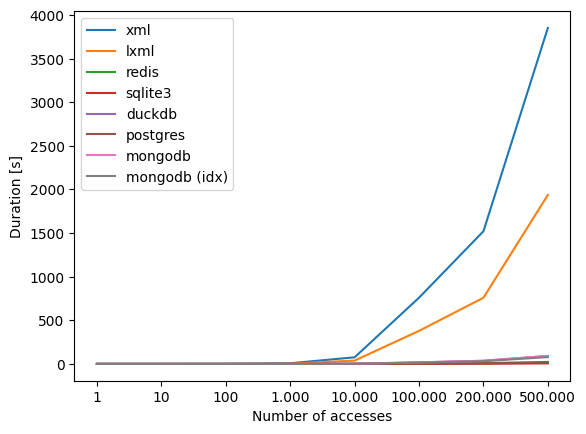

In [14]:
if not os.path.exists("../data/plots/"):
    os.makedirs("../data/plots/")

cols = [c for c in df.columns if c != 'db']

categories=[f"{x:,.0f}".replace(',', '.') for x in cols]

for _, row in df.iterrows():
    plt.plot(categories, row[cols], label=row['db'])
    #plt.plot(row[cols], cols, label=row['db'])

plt.xlabel("Number of accesses")
plt.ylabel("Duration [s]")
plt.legend()
plt.savefig('../data/plots/performance_all.pdf')
plt.show()

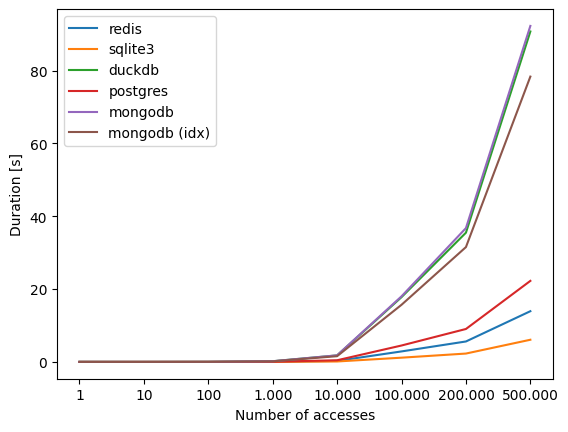

In [15]:
df2=df[(df['db']!='xml') & (df['db']!='lxml')]
cols = [c for c in df2.columns if c != 'db']
categories=[f"{x:,.0f}".replace(',', '.') for x in cols]

for _, row in df2.iterrows():
    plt.plot(categories, row[cols], label=row['db'])

plt.xlabel("Number of accesses")
plt.ylabel("Duration [s]")

plt.legend()
plt.savefig('../data/plots/performance_no_xml.pdf')
plt.show()

In [16]:
df_init=pd.DataFrame(init_times)
df_init

,db,duration
0,xml,0.007644
1,lxml,0.007644
2,redis,0.032061
3,sqlite3,0.155643
4,duckdb,10.525828
5,postgres,2.643235
6,mongodb,0.081457
7,mongodb (idx),0.065449


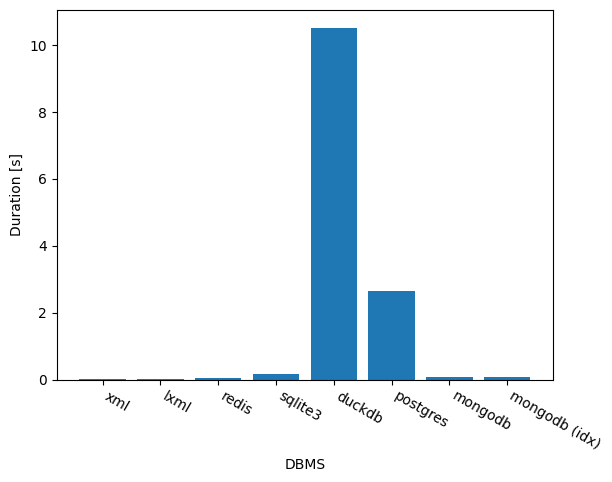

In [17]:
plt.bar(df_init['db'], df_init['duration'], label=row['db'])
plt.xticks(rotation=330,ha='left')

plt.xlabel("DBMS")
plt.ylabel("Duration [s]")

plt.savefig('../data/plots/init_all.pdf')
plt.show()

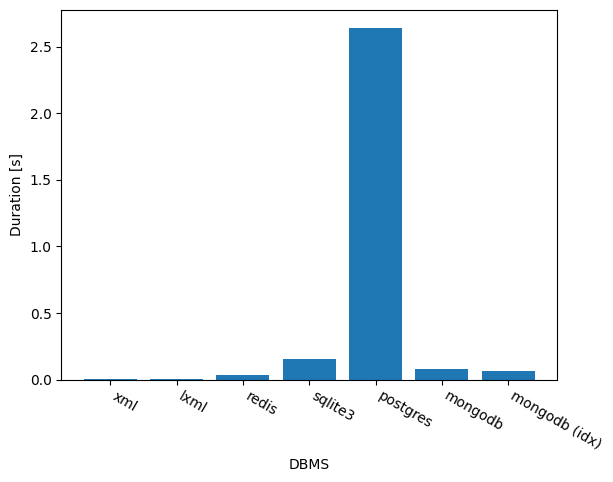

In [18]:
df3=df_init[(df_init['db']!='duckdb')]

plt.bar(df3['db'], df3['duration'], label=row['db'])
plt.xticks(rotation=330,ha='left')

plt.xlabel("DBMS")
plt.ylabel("Duration [s]")

plt.savefig('../data/plots/init_all_no_duckdb.pdf')
plt.show()

In [19]:
# save the dataframe for later usage
# only uncomment the next three lines if you REALLY want to override all saved data
df.to_pickle("../data/df.pickle")
df_init.to_pickle("../data/df_init.pickle")
df_backup=df
last_updated=datetime.now()
print(f"Saved last at: {last_updated}")

Saved last at: 2026-05-18 13:17:39.692370


### Comparison between Systems

Score were obtained from:
- https://browser.geekbench.com/macs/mac-studio-apple-m1-ultra
- https://browser.geekbench.com/macs/macbook-air-13-inch-2025-10c-cpu-10c-gpu

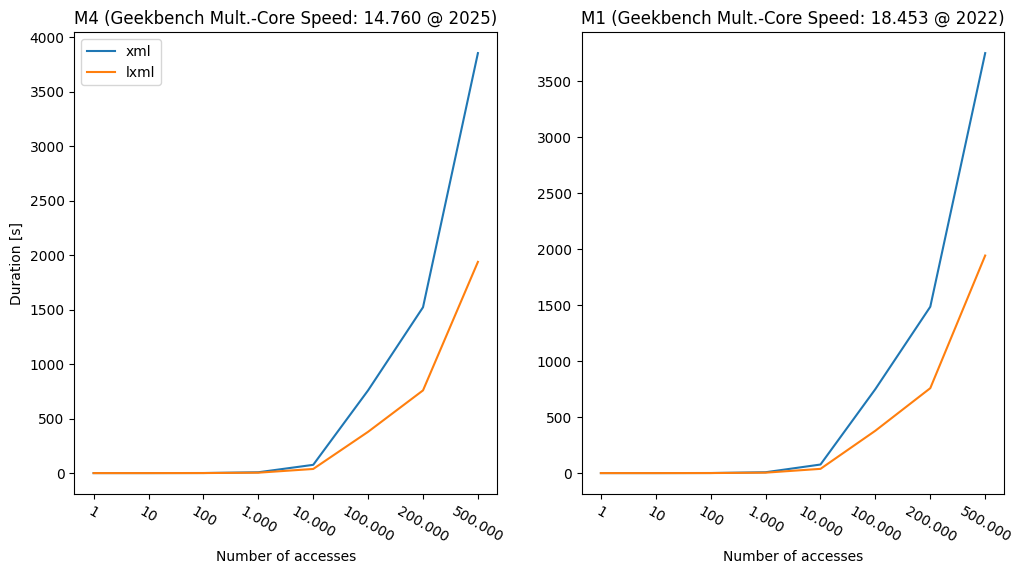

In [20]:
c2_path="../data/m1/df.pickle"
c1_path="../data/m4/df.pickle"
c2_title="M1 (Geekbench Mult.-Core Speed: 18.453 @ 2022)"
c1_title="M4 (Geekbench Mult.-Core Speed: 14.760 @ 2025)"

comparison_possible=False
if os.path.exists(c1_path) and os.path.exists(c2_path):
    c1=pickle.load(open(c1_path, "rb"))
    c2=pickle.load(open(c2_path, "rb"))
    comparison_possible=True
else:
    print("☠️ Data not available. Comparison will not be possible!")

if comparison_possible:
    c1_xml=c1[(c1['db']=='xml') | (c1['db']=='lxml')]
    c2_xml=c2[(c2['db']=='xml') | (c2['db']=='lxml')]

    cols1 = [c for c in c1_xml.columns if c != 'db']
    categories1=[f"{x:,.0f}".replace(',', '.') for x in cols1]
    cols2 = [c for c in c2_xml.columns if c != 'db']
    categories2=[f"{x:,.0f}".replace(',', '.') for x in cols2]

    # actual plotting
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))

    for _, row in c1_xml.iterrows():
        ax[0].plot(categories1, row[cols1], label=row['db'])

    ax[0].tick_params(axis='x',labelrotation=330,labelleft=True)
    ax[0].set_xlabel("Number of accesses")
    ax[0].set_ylabel("Duration [s]")
    ax[0].set_title(c1_title)

    y_val1=c1_xml[c1_xml['db']=='xml'][500000][0]
    #ax[0].annotate("{:.2f}".format(y_val1).replace(".",","),xy=(7, y_val1), xytext=(3, y_val1), arrowprops=dict(arrowstyle="->"),horizontalalignment='right', verticalalignment='top')
    y_val1_lxml=c1_xml[c1_xml['db']=='lxml'][500000][1]
    #ax[0].annotate("{:.2f}".format(y_val1_lxml).replace(".",","),xy=(7, y_val1_lxml), xytext=(3, y_val1_lxml), arrowprops=dict(arrowstyle="->"),horizontalalignment='right', verticalalignment='top')

    ax[0].legend()

    for _, row in c2_xml.iterrows():
        ax[1].plot(categories2, row[cols2], label=row['db'])

    ax[1].tick_params(axis='x',labelrotation=330,labelleft=True)

    ax[1].set_xlabel("Number of accesses")
    #ax[1].set_ylabel("Duration [s]")
    ax[1].set_title(c2_title)


    y_val2=c2_xml[c2_xml['db']=='xml'][500000][0]
    #ax[1].annotate("{:.2f}".format(y_val2).replace(".",","),xy=(7, y_val2), xytext=(3, y_val2), arrowprops=dict(arrowstyle="->"),horizontalalignment='right', verticalalignment='top')

    y_val2_lxml=c2_xml[c2_xml['db']=='lxml'][500000][1]
    #ax[1].annotate("{:.2f}".format(y_val2_lxml).replace(".",","),xy=(7, y_val2_lxml), xytext=(3, y_val2_lxml), arrowprops=dict(arrowstyle="->"),horizontalalignment='right', verticalalignment='top')


    plt.savefig('../data/plots/comp_performance_all_xml.pdf')
    plt.show()
else:
    print("☠️ Data not available. Comparison will not be possible!")

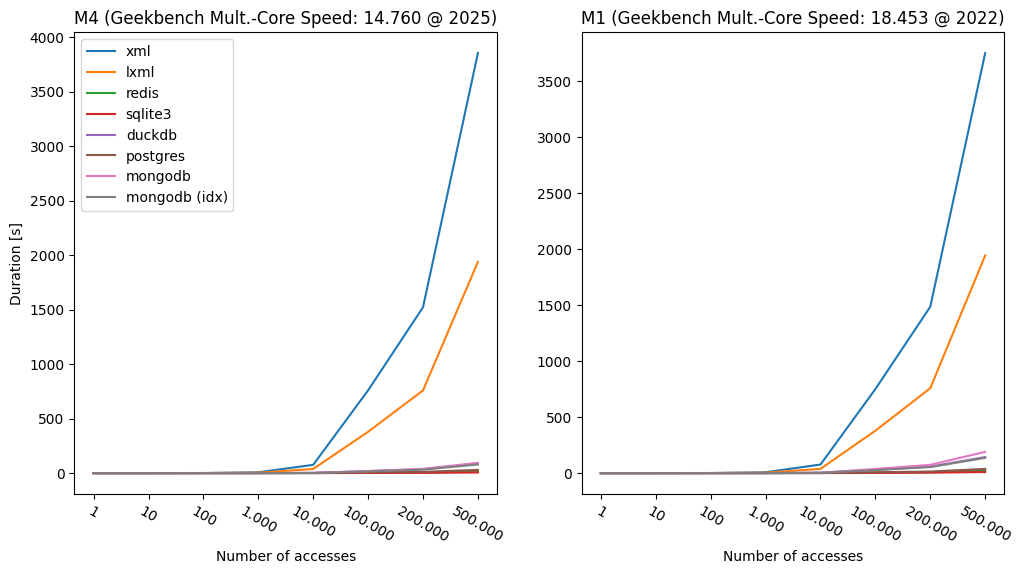

In [21]:
if comparison_possible:
    cols1 = [c for c in c1.columns if c != 'db']
    categories1=[f"{x:,.0f}".replace(',', '.') for x in cols1]
    cols2 = [c for c in c2.columns if c != 'db']
    categories2=[f"{x:,.0f}".replace(',', '.') for x in cols2]

    # actual plotting
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))

    for _, row in c1.iterrows():
        ax[0].plot(categories1, row[cols1], label=row['db'])

    ax[0].tick_params(axis='x',labelrotation=330,labelleft=True)
    ax[0].set_xlabel("Number of accesses")
    ax[0].set_ylabel("Duration [s]")
    ax[0].set_title(c1_title)
    ax[0].legend()

    for _, row in c2.iterrows():
        ax[1].plot(categories2, row[cols2], label=row['db'])

    ax[1].tick_params(axis='x',labelrotation=330,labelleft=True)

    ax[1].set_xlabel("Number of accesses")
    #ax[1].set_ylabel("Duration [s]")
    ax[1].set_title(c2_title)


    plt.savefig('../data/plots/comp_performance_all.pdf')
    plt.show()
else:
    print("☠️ Data not available. Comparison will not be possible!")

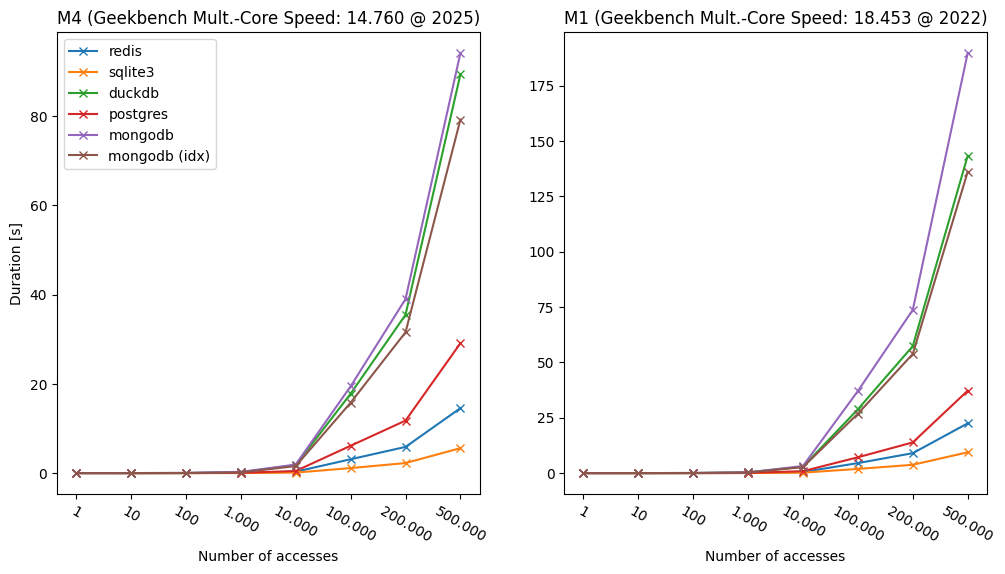

In [22]:
if comparison_possible:
    c1=c1[(c1['db']!='xml') & (c1['db']!='lxml')]
    c2=c2[(c2['db']!='xml') & (c2['db']!='lxml')]

    cols1 = [c for c in c1.columns if c != 'db']
    categories1=[f"{x:,.0f}".replace(',', '.') for x in cols1]
    cols2 = [c for c in c2.columns if c != 'db']
    categories2=[f"{x:,.0f}".replace(',', '.') for x in cols2]

    # actual plotting
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))

    for _, row in c1.iterrows():
        ax[0].plot(categories1, row[cols1], label=row['db'],marker='x')

    ax[0].tick_params(axis='x',labelrotation=330,labelleft=True)
    ax[0].set_xlabel("Number of accesses")
    ax[0].set_ylabel("Duration [s]")
    ax[0].set_title(c1_title)
    ax[0].legend()

    for _, row in c2.iterrows():
        ax[1].plot(categories2, row[cols2], label=row['db'],marker='x')

    ax[1].tick_params(axis='x',labelrotation=330,labelleft=True)

    ax[1].set_xlabel("Number of accesses")
    #ax[1].set_ylabel("Duration [s]")
    ax[1].set_title(c2_title)
    #ax[1].legend()

    plt.savefig('../data/plots/comp_performance_no_xml.pdf')
    plt.show()
else:
    print("☠️ Data not available. Comparison will not be possible!")

In [23]:
print(f"Done at: {datetime.now()} with {fake_k} fake records.")

Done at: 2026-05-18 13:17:40.208229 with 100000 fake records.
